# Chunking Documents
Splitting provided documents into digestible chunks to enable efficient, relevant information retrieval and category classification.

## Isolating Data
Extracting data related to the 10 core categories. TODO: substitute with finalized train-validation split 

In [24]:
import json
import pandas as pd
from IPython.display import display, Markdown


In [15]:
# change depending on running in Colab or local
ROOT_DIR = '..'

In [16]:
# filter dataframe to include only rows within the 10 selected categories
df = pd.read_csv('../data/cuad/cleaned_train_df.csv')

CATEGORIES = ['Parties',
              'Document Name',
              'Agreement Date',
              'Governing Law',
              'Expiration Date',
              'Anti-Assignment',
              'License Grant',
              'Cap On Liability',
              'Audit Rights',
              'Exclusivity']

df = df[df['category'].isin(CATEGORIES)]
df.shape

(7292, 51)

In [ ]:
# pull contracts corresponding to the filtered categories
titles = df['title'].unique()
print(df['title'].nunique())

408


In [30]:
# TODO: replace with actual train val split when available
from sklearn.model_selection import train_test_split

# one row per contract, columns = core-category positive flags
contract_labels = (
    df[df['category'].isin(CATEGORIES)]
    .assign(has_answer=lambda d: d['has_answer'].astype(int))
    .pivot_table(index='title', columns='category', values='has_answer', aggfunc='max', fill_value=0)
)

# simple stratify proxy: bucket by count of positive categories per contract
strat_key = contract_labels.sum(axis=1).clip(upper=3)  # cap to avoid tiny bins

train_titles, val_titles = train_test_split(
    contract_labels.index,
    test_size=0.15,
    random_state=42,
    stratify=strat_key,
)

train_df = df[df['title'].isin(train_titles)]
val_df   = df[df['title'].isin(val_titles)]

# sanity check: make sure the train and validation splits do not overlap
assert set(train_titles).isdisjoint(set(val_titles)), "Train and validation sets overlap"
print(f"Number of training titles: {len(train_titles)}")
print(f"Number of validation titles: {len(val_titles)}")


Number of training titles: 346
Number of validation titles: 62


Extract the training titles into separate .txt files, keeping the validation titles untouched:

In [32]:
# TODO: migrate to a working script
import re
from pathlib import Path

with open('../data/cuad/train_separate_questions.json', encoding='utf-8') as f:
    data = json.load(f)['data']

out_dir = Path('../data/cuad/contracts_txt')
out_dir.mkdir(parents=True, exist_ok=True)

def safe_filename(title: str) -> str:
    # titles can contain characters invalid on Windows filesystems
    return re.sub(r'[<>:"/\\|?*]', '_', title).strip()

for contract in data:
    print(f"Processing contract: {contract['title']}")
    title = contract['title']
    if title not in train_titles:
        continue
    # contracts have a single paragraph holding the full text
    context = contract['paragraphs'][0]['context']
    filename = safe_filename(title) + '.txt'
    (out_dir / filename).write_text(context, encoding='utf-8')
print(f"Wrote {sum(1 for i in data if i['title'] in train_titles)} contract files to {out_dir}")



Processing contract: LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGREEMENT
Processing contract: WHITESMOKE,INC_11_08_2011-EX-10.26-PROMOTION AND DISTRIBUTION AGREEMENT
Processing contract: NELNETINC_04_08_2020-EX-1-JOINT FILING AGREEMENT
Processing contract: ADAMSGOLFINC_03_21_2005-EX-10.17-ENDORSEMENT AGREEMENT
Processing contract: KIROMICBIOPHARMA,INC_05_11_2020-EX-10.23-CONSULTING AGREEMENT
Processing contract: VEONEER,INC_02_21_2020-EX-10.11-JOINT VENTURE AGREEMENT
Processing contract: MetLife, Inc. - Remarketing Agreement
Processing contract: FTENETWORKS,INC_02_18_2016-EX-99.4-STRATEGIC ALLIANCE AGREEMENT
Processing contract: DOMINIADVISORTRUST_02_18_2005-EX-99.(H)(2)-SPONSORSHIP AGREEMENT
Processing contract: PfHospitalityGroupInc_20150923_10-12G_EX-10.1_9266710_EX-10.1_Franchise Agreement3
Processing contract: CerenceInc_20191002_8-K_EX-10.4_11827494_EX-10.4_Intellectual Property Agreement
Processing contract: ReynoldsConsumerProductsInc_20191115_S-1_EX-10.18_11896469_EX-10.18_Sup

## Examining contract contents:
Naturally, the legal contracts here are quite formulaic. Examining one of the contracts, *ADUROBIOTECH,INC_06_02_2020-EX-10.7-CONSULTING AGREEMENT*, we see a broad division into numbered sections, lettered subsections, and clauses.

In [34]:
with open('../data/cuad/contracts_txt/ADUROBIOTECH,INC_06_02_2020-EX-10.7-CONSULTING AGREEMENT.txt', encoding='utf-8') as f:
    content = f.read()
display(Markdown(content))

Exhibit 10.7

CONSULTING AGREEMENT

Aduro Biotech, Inc., with a place of business at 740 Heinz Avenue, Berkeley, CA 94710 ("Aduro") and IREYA B.V having an address at Staalwijkstraat 16, 2313 XR Leiden, the Netherlands, represented by Andrea van Elsas, ("Consultant") agree to all terms and conditions of this Consulting Agreement ("Agreement") dated June 1, 2020, effective as of July 1, 2020 ("Effective Date").

1. Services. At the request and direction of Aduro and the agreement of Consultant, Consultant will provide advice and consultation to Aduro with respect to its research, clinical development programs and other business matters as requested by Aduro from time to time.

2. Compensation and Expenses. Aduro shall pay Consultant for the Services at the rate of €500 per hour. On a monthly basis, Consultant shall submit to Aduro an invoice for the hours worked along with itemized documentation and receipts and other information for pre-approved travel and/or out-of- pocket expenses as Aduro reasonably requests at the time reimbursement is requested. Consultant will not incur any travel and/or other out-of-pocket expenses of more than €5,000 individually or €20,000 in the aggregate without the prior written consent of Aduro. Aduro shall pay Consultant any amounts due that are not reasonably disputed by Aduro, by check or direct bank deposit, within thirty days after receiving the invoice. Consultant's sole compensation for the Services shall be the amounts set forth above in this Section 2. Invoices shall be sent to the attention of:

ap@aduro.com Attn: Accounts Payable

3. Term of Agreement. This Agreement shall begin on the Effective Date and shall continue until December 31, 2020, unless extended or earlier terminated. Either party may terminate this Agreement at any time on prior written notice to the other. This Agreement may be extended upon mutual written agreement of the parties.

4. Confidential Information.

(a) "Confidential Information" means any information, materials or methods in whatever form or embodiment that has not been made available by Aduro to the general public and any information, materials or methods in the possession or control of Consultant on the Effective Date or developed in the performance of the Services, except that Confidential Information shall not include any information, material or method that (i) at the time of disclosure is in, or after disclosure becomes part of the public domain, through no improper act on the part of Consultant or any of its employees; (ii) was in Consultant's possession at the time of disclosure, as shown by written evidence, and was not acquired, directly or indirectly, from work with Aduro; or (iii) Consultant receives from a third party, provided that such Confidential Information was not obtained by such third party, directly or indirectly, from Aduro.

Specific information disclosed as part of the Confidential Information shall not be deemed to be in the public domain or in the prior possession of Consultant merely because it is encompassed or contemplated by more general information in the public domain or in the prior possession of the Consultant. Failure to mark any of the Confidential Information as confidential or proprietary shall not affect its status as Confidential Information under the terms of this Agreement.





(b) Consultant shall keep all Confidential Information confidential, and Consultant shall not disclose, disseminate, publish, reproduce or use Confidential Information except to perform the Services. If Consultant is required by judicial or administrative process to disclose Confidential Information, Consultant shall promptly notify Aduro to allow Aduro a reasonable time to oppose such process and Consultant shall reasonably cooperate in Aduro's efforts.

(c) On Aduro's request, or upon the termination or expiration of this Agreement, Consultant shall immediately: (i) stop using Confidential Information; (ii) return all materials provided by Aduro to Consultant that contain Confidential Information, except for one copy that may be retained by Consultant's legal counsel to confirm compliance with the obligations under this Agreement; (iii) destroy all copies of Confidential Information in any form including Confidential Information contained in computer memory or data storage apparatus or materials prepared by or for Consultant; and (iv) provide a written warranty to Aduro that Consultant has taken all the actions described in the foregoing Subparagraphs 4(c)(i-iii).

(d) Any breach of this Paragraph 4 by an employee or agent of Consultant shall be deemed to be a breach by Consultant.

(e) Defend Trade Secrets Act Notice: Nothing herein shall prevent Consultant from reporting possible violations of federal or state law or regulation to any governmental agency or entity, or making other disclosures that are protected under the whistleblower provisions of federal or state law or regulation. Consultant does not need the prior authorization of Aduro to make any such reports or disclosures and is not required to notify Aduro that it has made such reports or disclosures. In addition, as set forth in 18 U.S.C. §1833(b), Consultant shall not be held criminally or civilly liable under any federal or state trade secret law for the disclosure of a trade secret that is made in confidence to a federal, state or local government official, either directly or indirectly, or to an attorney, and that is made solely for the purpose of reporting or investigating a suspected violation of law, or that is made in a complaint or other document filed in a lawsuit or other proceeding if such filing is made under seal.

5. Independent Contractor. Consultant's relationship to Aduro shall be that of an independent contractor. Consultant shall be responsible for the timely payment of his or her own self-employment and income taxes. Neither party shall have any authority to bind the other.

6. Intellectual Property. Aduro shall be the sole and exclusive owner of, and Consultant hereby assigns to Aduro, any and all writings, documents, work product, inventions, developments, improvements, discoveries, know-how, processes, chemical entities, compounds, plans, memoranda, tests, research, designs, specifications, models and data that Consultant makes, conceives, discovers or develops, either solely or jointly with any other person in performance of the Services (collectively, "Work Product"). Consultant shall promptly disclose to Aduro all information relating to Work Product as appropriate as part of the Services and at the request of Aduro. To the extent, if any, that Consultant has rights in or to any Work Product or any data or inventions developed in connection with work under this Agreement ("Aduro IP"), Consultant hereby irrevocably assigns and transfers to Aduro, and to the extent that an executory assignment is not enforceable, Consultant hereby agrees to assign and transfer to Aduro, in writing, from time to time, upon request, any and all right, title, or interest that Consultant has or may obtain in any Work Product and/or Aduro IP without the necessity of further consideration. Aduro shall be entitled to obtain and hold in its own name all copyrights, patents, trade secrets and trademarks with respect thereto. At Aduro's request and expense, Consultant shall assist Aduro in acquiring and maintaining its right in and title to, any Work Product. Such assistance may include, but will not be limited to, signing applications and other documents, cooperating in legal proceedings, and taking any other steps considered necessary or desirable by Aduro.





7. Nonsolicitation. From the Effective Date and for twelve (12) months after the termination of this Agreement (the "Restricted Period"), Consultant shall not, without Aduro's prior written consent, directly or indirectly, solicit or encourage any employee or contractor of Aduro or its affiliates to terminate employment with, or cease providing Services to, Aduro or its affiliates. In the event of a breach of this Paragraph 7 by Consultant, Aduro shall be entitled to entry of injunctive relief. Such injunctive remedy shall be nonexclusive and shall be in addition to any and all other remedies which may be available to it at law or in equity, including without limitation, the recovery of direct, indirect, incidental, consequential and/or punitive damages.

8. Representations. Consultant represents as follows:

(a) Consultant is not subject to any other agreement that Consultant will violate by signing this Agreement;

(b) Consultant has and shall continue to have the knowledge, experience, qualifications and required skill to perform, and shall perform, the Services in a professional manner;

(c) Consultant to perform the Services in accordance with all Applicable Law; and

(d) During the term of this Agreement, Consultant will not, directly or indirectly (whether for compensation or without compensation) engage in or provide consulting services, or enter into any agreement either written or oral, that would present a material conflict with any of the provisions of this Agreement, or would preclude Consultant from complying with the terms and conditions hereof. If during the term of this Agreement any situation or circumstance arises that might reasonably be expected to present a conflict of interest, or if Consultant might be unable to render Services or otherwise participate in such work without risk of breaching an obligation of confidentiality to another party, Consultant will promptly advise the Company's General Counsel of the situation and Company and Consultant shall, in good faith, attempt to resolve any such conflicts(s). If requested by the Company's General Counsel, Consultant will recuse herself from providing Services for the duration of the conflict.

9. Material Non-Public Information. Consultant may have access to, or learn, "material non-public information" about Aduro or companies working with Aduro during the course of performing Services under this Agreement. Consultant acknowledges that it is illegal to buy or sell Aduro's stock or the stock of companies working with Aduro, on the basis of "material non-public information." It is also illegal to pass such information on to others who use it to buy or sell Aduro stock. Consultant is subject to and will comply with Aduro's Insider Trading and Trading Window Policy.

10. Miscellaneous. This Agreement shall be construed and enforced in accordance with the laws of the State of California, without regard to the conflict of law principles of California or any other jurisdiction. This Agreement contains the entire agreement and understanding of the parties relating to the subject matter hereof and merges and supersedes all prior discussions, agreements and understandings of every nature between them with respect to the subject matter hereof. For the avoidance of doubt, this Agreement does not supersede or in modify in anyway any other written agreement between the parties. This Agreement may not be changed or modified, except by an agreement in writing signed by both of the parties hereto. The obligations of Consultant as set forth herein, other than Consultant's obligations to perform the Project, shall survive the termination of Consultant's engagement with Aduro. If any provision of this Agreement is found to be illegal or unenforceable, the other provisions of this Agreement shall remain effective and enforceable to the greatest extent permitted by law. This Agreement shall not be assignable by Consultant. This Agreement may be executed in any number of counterparts, and each such counterpart shall be deemed to be an original instrument, but all such counterparts together shall constitute but one agreement.





ADURO BIOTECH, INC. CONSULTANT

By: /s/ Stephen T. Isaacs By: /s/ Andrea van Elsas Name: Stephen T. Isaacs Name: Andrea van Elsas Title: President and Chief Executive Officer Title: Chief Scientific Officer

Our ultimate goal is clause-based risk scoring, so naturally we want to chunk by clauses, which generally span a sentence to a paragraph, per the colloquial definition. We already have a measure of median answer length, and we specifically selected categories with relatively low clause length variance in our [EDA notebook](../01_EDA.ipynb), which we will use to guide decisions for chunk length.

Let's analyze median word count and answer length on our training set:

In [37]:
# isolate metrics from training dataframe
train_df['num_words'] = train_df['answer_text'].str.split().str.len()

category_stats = train_df.groupby('category').agg(
    n_answered=('has_answer', 'sum'),
    impossible_rate=('is_impossible', 'mean'),
    words_median=('num_words', 'median'),
    len_mean=('answer_len', 'mean'),
    len_std=('answer_len', 'std'),
).sort_values('n_answered', ascending=False)

category_stats['len_cv'] = category_stats['len_std'] / category_stats['len_mean']
category_stats.round(2)

C:\Users\wanga\AppData\Local\Temp\ipykernel_60780\3156007834.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df['num_words'] = train_df['answer_text'].str.split().str.len()


,n_answered,impossible_rate,words_median,len_mean,len_std,len_cv
category,,,,,,
Parties,1677,0.00,2.0,22.60,24.35,1.08
License Grant,546,0.24,55.0,448.60,325.15,0.72
Audit Rights,475,0.29,40.0,312.49,225.96,0.72
Cap On Liability,452,0.25,49.0,385.55,259.48,0.67
Anti-Assignment,435,0.17,35.0,293.32,210.26,0.72
Document Name,353,0.00,3.0,29.74,18.84,0.63
Agreement Date,325,0.08,3.0,18.63,10.97,0.59
Expiration Date,324,0.16,31.0,231.23,146.83,0.63
Governing Law,319,0.13,30.0,207.99,100.78,0.48


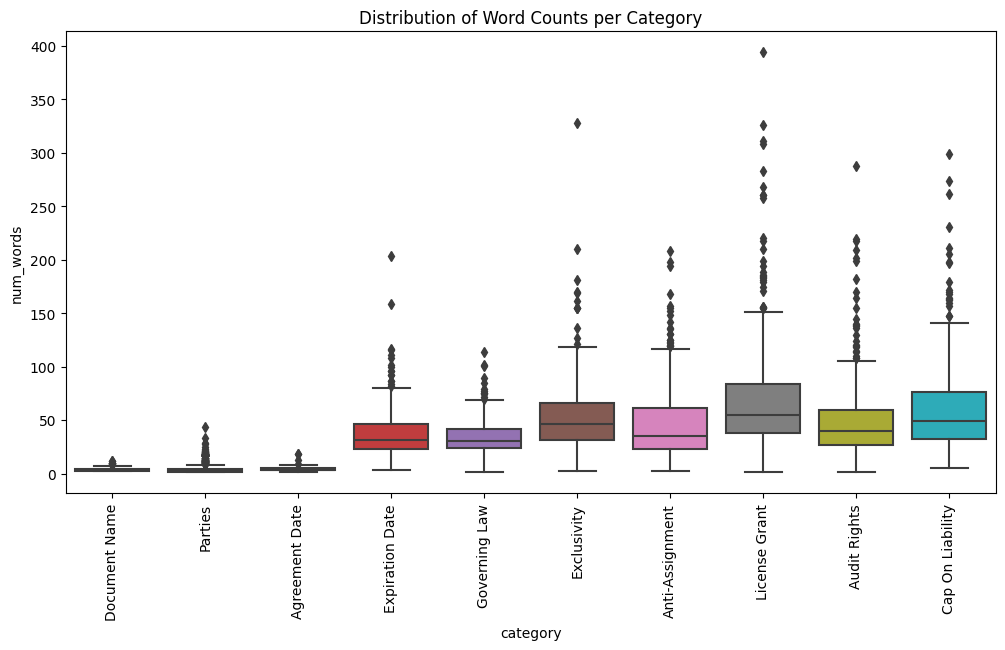

In [40]:
# actually why are we using words_median in the first place? 
# look at the distribution of word counts per category
# TODO: add an augmented (41-category) version of this plot into eda/september milestone report

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.boxplot(x='category', y='num_words', data=train_df)
plt.xticks(rotation=90)
plt.title('Distribution of Word Counts per Category')
plt.show()

C:\Users\wanga\AppData\Local\Temp\ipykernel_60780\2154145377.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df['median_len'] = train_df.groupby('category')['answer_text'].transform(lambda x: x.str.len().median())


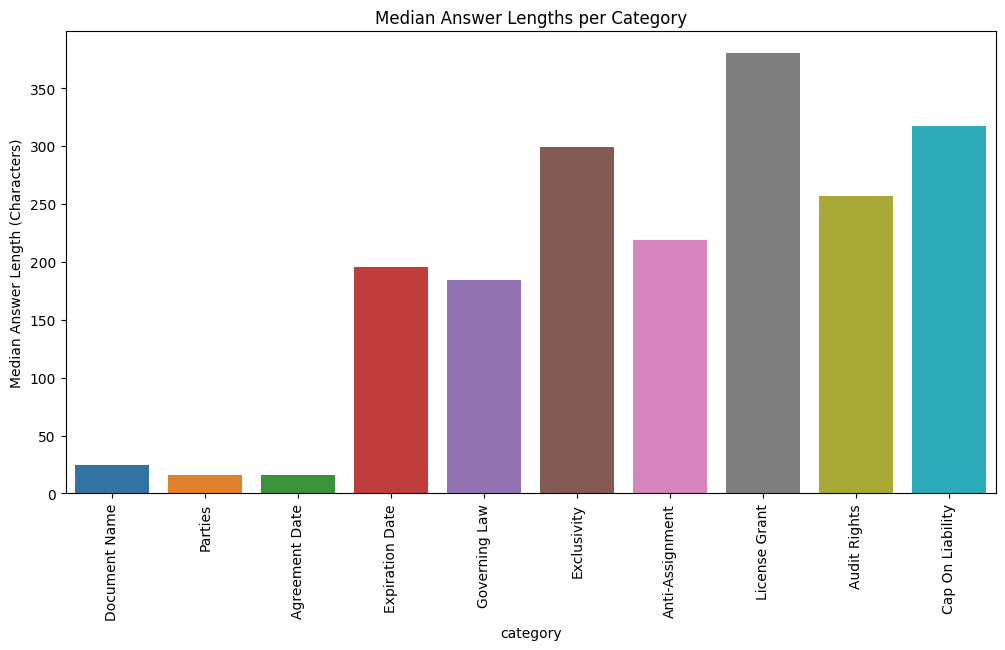

In [57]:
# let's look at median len... that's the most direct metric to reference for splitting
train_df['median_len'] = train_df.groupby('category')['answer_text'].transform(lambda x: x.str.len().median())

plt.figure(figsize=(12, 6))
sns.barplot(x='category', y='median_len', data=train_df)
plt.ylabel('Median Answer Length (Characters)')
plt.xticks(rotation=90)
plt.title('Median Answer Lengths per Category')
plt.show()


In [61]:
category_stats['median_len'] = train_df.groupby('category')['answer_text'].transform(lambda x: x.str.len().median())
train_df.groupby('category')['answer_text'].transform(lambda x: x.str.len().median())
# category_stats.head().round(2)

0         25.0
1         16.0
2         16.0
3         16.0
4         16.0
         ...  
22414    299.0
22422    219.0
22432    380.0
22440    257.0
22442    317.5
Name: answer_text, Length: 6159, dtype: float64

## Chunking with `RecursiveCharacterTextSplitter`
Brief justification for using LangChain's `RecursiveCharacterTextSplitter`.

In [ ]:
# from langchain_community.document_loaders import TextLoader
# from langchain_text_splitters import RecursiveCharacterTextSplitter